# Matrix Calculations using Numpy
Source : Xavier Dupre

[numpy arrays](https://docs.scipy.org/doc/numpy/reference/generated/numpy.array.html) are the first things to consider when designing a Python algorithm. 
Matrices are used in most algorithms and *numpy* has implemented optimized matrix operations.

In [1]:
%matplotlib inline

## Numpy arrays

In [3]:
import numpy as np

## Array creation: datatype, dimensions


Start with a Python list containing integers.

Create a numpy array from this list. 

This array has attributes indicating the data type, the number of dimensions of the array, etc.

In [4]:
l = [1, 42, 18 ]
a = np.array(l)
print(a)
print(a.dtype)
print(a.ndim)
print(a.shape)
print(a.size)
a


[ 1 42 18]
int32
1
(3,)
3


array([ 1, 42, 18])

You can explicitely precise the [dtype](http://docs.scipy.org/doc/numpy/reference/generated/numpy.dtype.html) during array creation . Otherwise, numpy will select it automatically.
Numpy extends the number of types that already exist in Python. You can check the full [list](http://docs.scipy.org/doc/numpy/user/basics.types.html). 

In [5]:
b = np.array(l, dtype=float)
print(b)
print(b.dtype)

[ 1. 42. 18.]
float64


In [6]:
l[0] = 1.0
bb = np.array(l)
print(bb)
print(bb.dtype)

[ 1. 42. 18.]
float64


Assigning a float to an array of type 'int' will transform the float to an integer, and will not change the array's dtype.

In [8]:
a[0] = 2.5 
print(a)
print(a.dtype)

[ 2 42 18]
int32


You can force type casting using [astype](http://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.astype.html) :

In [9]:
aa = a.astype(float)
aa[0] = 2.5
aa

array([ 2.5, 42. , 18. ])

From a list of lists, you can get a bi-dimensional array.

This array can be transposed or flattend into a 1d array.

In [10]:
c = np.array([range(5), range(5,10), range(5)])
print(c)
print("ndim:{}".format(c.ndim))
print("shape:{}".format(c.shape))
print(c.transpose()) #same as c.T
print("shape transposed:{}".format(c.T.shape))
print(c.flatten())
print("ndim flattened:{}".format(c.flatten().ndim))

[[0 1 2 3 4]
 [5 6 7 8 9]
 [0 1 2 3 4]]
ndim:2
shape:(3, 5)
[[0 5 0]
 [1 6 1]
 [2 7 2]
 [3 8 3]
 [4 9 4]]
shape transposed:(5, 3)
[0 1 2 3 4 5 6 7 8 9 0 1 2 3 4]
ndim flattened:1


## Indexation, Slicing, Fancy indexing

In [11]:
print(c)

[[0 1 2 3 4]
 [5 6 7 8 9]
 [0 1 2 3 4]]


The ``':'`` syntax allows getting part or all of the elements of a multidimensional array, along a specific dimension.

In [15]:
print(c[1,3])
print(c[1,:3])
print(c[:,4])

8
[5 6 7]
[4 9 4]


If you call an array like a list, using only one index, you will get a 1D array.

In [17]:
print(c[1], c[1].shape)
print(c[1][:3])

[5 6 7 8 9] (5,)
[5 6 7]


We can also use indexation using an array (or a list) of booleans or ints (also called a mask). This is called "fancy indexing". A mask of ints allows to designate elements that we want to extract given a list of indices. We can also repeat the index to repeat the element that is extracted.

In [22]:
ar = np.arange(1,10) #arange is equivalent to range with a numpy array
print('ar = ',ar)
idx = np.array([1, 4, 3, 2, 1, 7, 3])
print('idx = ',idx)
print("ar[idx] =", ar[idx])
print('\n')
idx_bool = np.ones(ar.shape, dtype=bool)
idx_bool[idx] = False
print('idx_bool = ', idx_bool)
print('ar[idx_bool] = ', ar[idx_bool])
print('\n')
print('######', 'What happens in each of the following cases?', '######' )
try:
    print('ar[np.array([True, True, False, True])] = ', ar[np.array([True, True, False, True])])
except Exception as e:
    # The expression ar[[True, True, False, True]] causes an error since numpy 1.13
    print("Erreur", e)

ar =  [1 2 3 4 5 6 7 8 9]
idx =  [1 4 3 2 1 7 3]
ar[idx] = [2 5 4 3 2 8 4]


idx_bool =  [ True False False False False  True  True False  True]
ar[idx_bool] =  [1 6 7 9]


###### What happens in each of the following cases? ######
Erreur boolean index did not match indexed array along dimension 0; dimension is 9 but corresponding boolean dimension is 4


Why do we talk about fancy indexing ? Try indexing python lists in the same way.

In [ ]:
list_python = range(10)
list_python[[True, True, False, True]] # causes an error

TypeError: range indices must be integers or slices, not list

In [ ]:
list_python[[2, 3, 2, 7]]  # causes an error

TypeError: range indices must be integers or slices, not list

#### View vs Copy

Create an array $d$. The ```arange``` function not only returns an array, but it also allows to use a float step.

In [26]:
d = np.arange(1, 6, 0.5)
d

array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5])

An important point is that we don't copy an array when assigning or slicing an array.
In this case, we work with a View on the original array (shallow copy). Any modification to the View affects the original array.

In the following example, $e$ is a view on $d$. When $e$ is modified, $d$ is also modified. (Note that numpy provides some handy constants....)

In [27]:
e = d
e[[0,2, 4]] = - np.pi
e

array([-3.14159265,  1.5       , -3.14159265,  2.5       , -3.14159265,
        3.5       ,  4.        ,  4.5       ,  5.        ,  5.5       ])

In [28]:
d

array([-3.14159265,  1.5       , -3.14159265,  2.5       , -3.14159265,
        3.5       ,  4.        ,  4.5       ,  5.        ,  5.5       ])

If you don't want to modify $d$ indirectly, you must work on a copy of $d$ ([deep copy](https://docs.python.org/3.4/library/copy.html#copy.deepcopy)).

In [29]:
d = np.linspace(1,5.5,10) # Subsidiary question: how is it different from np.arange with a float step?
f = d.copy()
f[:4] = -np.e # np.e is the constant e, not the array [e] that we defined earlier
print(f)
print(d)

[-2.71828183 -2.71828183 -2.71828183 -2.71828183  3.          3.5
  4.          4.5         5.          5.5       ]
[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]


This is an important point, as it is a classic source of silent errors: the most vicious errors, as the output will be wrong, but Python won't complain...

It takes a little getting used to, but you'll come to know naturally when you're working on a view, when you need to make an explicit copy, etc... In any case, check your output, run consistency tests - it never hurts.

Remember, for example, that [slicing](http://docs.scipy.org/doc/numpy/reference/arrays.indexing.html#basic-slicing-and-indexing) returns a view on the array, whereas [fancy indexing](https://scipy-lectures.github.io/intro/numpy/array_object.html#fancy-indexing) makes a copy.


In [ ]:
print('d = ',d)
slice_of_d = d[2:5]
print('\nslice_of_d = ', slice_of_d)
slice_of_d[0] = np.nan
print('\nd = ', d)
mask = np.array([2, 3, 4])
fancy_indexed_subarray = d[mask]
print('\nfancy_indexed_subarray = ', fancy_indexed_subarray)
fancy_indexed_subarray[0] = -2
print('\nd = ', d)

## Shape manipulation

The reshape method is used to change the shape of the array. There are many [possible manipulations](http://docs.scipy.org/doc/numpy/reference/routines.array-manipulation.html).

We specify the desired shape at [reshape](http://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html): by an integer if we want a 1d array of this length, or a couple for a 2d array of this shape.

In [33]:
g = np.arange(12)
print(g)
g.reshape((4,3))

[ 0  1  2  3  4  5  6  7  8  9 10 11]


array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

By default, [reshape](http://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html) uses enumeration in the order of the C language (also known as “row first”), but you can specify that you wish to use the order of [Fortran](https://fr.wikipedia.org/wiki/Fortran) (“column first”). Those familiar with Matlab and R will be familiar with the “column-first” order. [See wikipedia article](http://en.wikipedia.org/wiki/Row-major_order)

In [34]:
g.reshape((4,3), order='F')

array([[ 0,  4,  8],
       [ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11]])

You can use -1 on a dimension as a wildcard: numpy infers the required dimension! Matrices of 0 and 1 can be created directly in the dimension of another array.

In [36]:
np.zeros_like(g)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [38]:
np.ones_like(g)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Different arrays can also be concatenated or stacked [horizontally](http://docs.scipy.org/doc/numpy/reference/generated/numpy.hstack.html)/[vertically](http://docs.scipy.org/doc/numpy/reference/generated/numpy.vstack.html).

In [39]:
np.concatenate((g, np.zeros_like(g))) #Pay attention to the syntax: the input type is a tuple!

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0])

In [40]:
gmat = g.reshape((1, len(g)))
np.concatenate((gmat, np.ones_like(gmat)), axis=0)

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1]])

In [41]:
np.concatenate((gmat, np.ones_like(gmat)), axis=1)

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1]])

In [42]:
np.hstack((g, g))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11])

In [43]:
np.vstack((g,g))

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]])

## Exercise 1: Chessboard

Create a chessboard matrix (alternating 1s and 0s) of size 8x8, in two different ways
* using slices 
* using the [tile] function (http://docs.scipy.org/doc/numpy/reference/generated/numpy.tile.html#numpy.tile)

In [47]:
#1

## Exercice 2: 2D extraction trap 
* Define matrix $M = \left(\begin{array}{ccccc} 1 & 5 & 9 & 13 & 17 \\ 2 & 6 & 10 & 14 & 18 \\ 3 & 7 & 11 & 15 & 19 \\ 4 & 8 & 12 & 16 & 20 \\ \end{array}\right)$
* **Extract** the following matrix from it $\left(\begin{array}{ccc} 6 & 18 & 10 \\ 7 & 19 & 11 \\ 5 & 17 & 9 \\ \end{array}\right)$

In [ ]:
#2

## Exercise 3 : Sieve of Erathosthenes

We wish to implement an [Erathosthenes' sieve](http://fr.wikipedia.org/wiki/Crible_d'%C3%89ratosth%C3%A8ne) to find the prime numbers less than $N=1000$.

* From an array of Booleans of size N+1, all equal to True.
* Set 0 and 1 to False as they are not prime.
* for each integer $k$ between 2 and $\sqrt{N}$: 
    * if $k$ is prime: set its multiples (between $k^2$ and $N$) to False
* print the list of prime integers

In [ ]:
#3

## Array manipulation & operations

There are many [routines for manipulating numpy arrays](http://docs.scipy.org/doc/numpy/reference/routines.html): 

You may find the specific pages for [stats](http://docs.scipy.org/doc/numpy/reference/routines.statistics.html) or [maths](http://docs.scipy.org/doc/numpy/reference/routines.math.html) routines useful.

### Element wise operations

Let us illustrate a few operations.

In [49]:
a = np.ones((3,2))
b = np.arange(6).reshape(a.shape)
print("a\n", a)
print("b\n", b)

a
 [[1. 1.]
 [1. 1.]
 [1. 1.]]
b
 [[0 1]
 [2 3]
 [4 5]]


Arithmetic operations with scalars, or between arrays, are performed element by element.
When the dtype is not the same ($a$ contains floats, $b$ contains int), numpy adopts the “largest” type (in the sense of inclusion).

In [50]:
print( "(a + b)**2\n", (a + b)**2 )
print( "np.abs( 3*a - b )\n", np.abs( 3*a - b ) )
f = lambda x: np.exp(x-1)
print( "f(b)\n" , f(b) )

(a + b)**2
 [[ 1.  4.]
 [ 9. 16.]
 [25. 36.]]
np.abs( 3*a - b )
 [[3. 2.]
 [1. 0.]
 [1. 2.]]
f(b)
 [[ 0.36787944  1.        ]
 [ 2.71828183  7.3890561 ]
 [20.08553692 54.59815003]]


Note that division by zero does not cause an error, but introduces the value [inf](http://docs.scipy.org/doc/numpy/reference/generated/numpy.isinf.html) :

In [53]:
b

array([[0, 1],
       [2, 3],
       [4, 5]])

In [54]:
1/b

C:\Users\u011513\AppData\Local\Temp\ipykernel_29612\4032182506.py:1: RuntimeWarning: divide by zero encountered in divide
  1/b


array([[       inf, 1.        ],
       [0.5       , 0.33333333],
       [0.25      , 0.2       ]])

### Broadcasting

What happens if dimension are different ?

In [55]:
c = np.ones(6)
c

array([1., 1., 1., 1., 1., 1.])

In [57]:
b+c   # causes an error

ValueError: operands could not be broadcast together with shapes (3,2) (6,) 

In [58]:
c = np.arange(3).reshape((3,1))
print(b,c, sep='\n')
b+c

[[0 1]
 [2 3]
 [4 5]]
[[0]
 [1]
 [2]]


array([[0, 1],
       [3, 4],
       [6, 7]])

The previous operation works because numpy performs what's called a ``c`` [broadcasting](http://docs.scipy.org/doc/numpy/user/basics.broadcasting.html): since one dimension is shared, everything happens as if we were duplicating c on the dimension not shared with b. You'll find a simple visual explanation [here](http://www.tp.umu.se/~nylen/pylect/intro/numpy/numpy.html#broadcasting) :

In [59]:
a = np.zeros((3,3))
a[:,0] = -1
b = np.array(range(3))
print(a + b)

[[-1.  1.  2.]
 [-1.  1.  2.]
 [-1.  1.  2.]]


On the other hand, it can sometimes be useful to specify the dimension on which you wish to broadcast, in which case you explicitly add a dimension :

In [60]:
print(b.shape)
print(b[:,np.newaxis].shape) 
print(b[np.newaxis,:].shape)

(3,)
(3, 1)
(1, 3)


In [61]:
print( a + b[np.newaxis,:] )
print( a + b[:,np.newaxis] )
print(b[:,np.newaxis]+b[np.newaxis,:])
print(b + b)

[[-1.  1.  2.]
 [-1.  1.  2.]
 [-1.  1.  2.]]
[[-1.  0.  0.]
 [ 0.  1.  1.]
 [ 1.  2.  2.]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]
[0 2 4]


### Reductions

Reductions occur when the operation reduces the size of the array.
There are many such operations. They often exist in the form of numpy functions or numpy array methods.
Only a few are presented here, but the principle is the same: by default, they operate on all dimensions, but the *axis* argument can be used to specify the dimension according to which the reduction is to be performed.

In [62]:
c = np.arange(10).reshape((2,-1)) #Note: -1 is a joker! 
print(c)
print(c.sum())
print(c.sum(axis=0))
print(np.sum(c, axis=1))

[[0 1 2 3 4]
 [5 6 7 8 9]]
45
[ 5  7  9 11 13]
[10 35]


In [63]:
print(np.all(c[0] < c[1]))
print(c.min(), c.max())
print(c.min(axis=1))

True
0 9
[0 5]


## Linear Algebra

You have a range of functions for doing linear algebra in [numpy](http://docs.scipy.org/doc/numpy/reference/routines.linalg.html) or in [scipy](http://docs.scipy.org/doc/scipy/reference/linalg.html).
This can be useful if you're looking to do a particular matrix decomposition ([LU](http://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.linalg.lu.html), [QR](http://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.qr.html), [SVD](http://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.svd.html),...), if you're interested in the eigenvalues of a matrix, etc...

### Simple example

Let's start by constructing two 2d arrays corresponding to a lower triangular matrix and a diagonal matrix :

In [64]:
A = np.tril(np.ones((3,3)))
A

array([[1., 0., 0.],
       [1., 1., 0.],
       [1., 1., 1.]])

In [65]:
b = np.diag([1,2, 3])
b

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])

We have seen that multiplications between arrays are carried out element by element.
If you wish to perform matrix multiplication, you need to use the [dot](http://docs.scipy.org/doc/numpy/reference/generated/numpy.dot.html) function. Version 3.5 introduces a new operator [@](https://docs.python.org/3.6/whatsnew/3.5.html#pep-465-a-dedicated-infix-operator-for-matrix-multiplication) which explicitly designates matrix multiplication.

In [66]:
print(A.dot(b))
print(A*b)
print(A.dot(A))

[[1. 0. 0.]
 [1. 2. 0.]
 [1. 2. 3.]]
[[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 3.]]
[[1. 0. 0.]
 [2. 1. 0.]
 [3. 2. 1.]]


We can calculate the inverse or determinant of $A$.

In [67]:
print(np.linalg.det(A))
inv_A = np.linalg.inv(A)
print(inv_A)
print(inv_A.dot(A))

1.0
[[ 1.  0.  0.]
 [-1.  1.  0.]
 [ 0. -1.  1.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


... solve systems of linear equations of the type $Ax = b$...

In [68]:
x = np.linalg.solve(A, np.diag(b))
print(np.diag(b))
print(x)
print(A.dot(x))

[1 2 3]
[1. 1. 1.]
[1. 2. 3.]


... or obtain the eigenvalues of $A$.

In [69]:
np.linalg.eig(A)

(array([1., 1., 1.]),
 array([[ 0.00000000e+00,  0.00000000e+00,  4.93038066e-32],
        [ 0.00000000e+00,  2.22044605e-16, -2.22044605e-16],
        [ 1.00000000e+00, -1.00000000e+00,  1.00000000e+00]]))

In [70]:
np.linalg.eigvals(A)

array([1., 1., 1.])

#### Numpy Matrix

[Matrix](http://docs.scipy.org/doc/numpy/reference/generated/numpy.matrix.html) is a specialized subclass for matrix calculation. It is a 2d numpy array that retains its 2d dimension throughout the operations. Think of the differences this implies...
They can be built conventionally from arrays or Python objects, or via a Matlab-style string (where semicolons indicate rows).

In [83]:
m = np.matrix(' 1 2 3; 4 5 6; 7 8 9')
a = np.arange(1,10).reshape((3,3))
print("m (np.matrix)\n", m)
print("a (np.array)\n", a)
print(m[0], a[0])
print(m[0].shape, a[0].shape)

m (np.matrix)
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
a (np.array)
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
[[1 2 3]] [1 2 3]
(1, 3) (3,)


Matrix also overloads the \* and \** operators to replace element-by-element operations with matrix operations.
Finally, a Matrix has additional attributes. In particular, Matrix.I designates the inverse, Matrix.A the base array. 

*This is likely to evolve as Python 3.5 introduces the ``@`` symbol for matrix multiplication.

In [72]:
m * m

matrix([[ 30,  36,  42],
        [ 66,  81,  96],
        [102, 126, 150]])

In [73]:
a * a

array([[ 1,  4,  9],
       [16, 25, 36],
       [49, 64, 81]])

In [76]:
m * a # La priorité des matrix est plus importantes que celles des arrays

matrix([[ 30,  36,  42],
        [ 66,  81,  96],
        [102, 126, 150]])

In [75]:
print(m**2)
print(a**2)

[[ 30  36  42]
 [ 66  81  96]
 [102 126 150]]
[[ 1  4  9]
 [16 25 36]
 [49 64 81]]


A lighter syntax for matrix calculations

In [84]:
m[0,0]= -1
print("det", np.linalg.det(m), "rank",np.linalg.matrix_rank(m))
print(m.I*m)
a[0,0] = -1
print("det", np.linalg.det(a), "rank",np.linalg.matrix_rank(a))
print(a.dot(np.linalg.inv(a)))

det 6.000000000000001 rank 3
[[ 1.00000000e+00  3.99680289e-15  4.49640325e-15]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-8.88178420e-16  0.00000000e+00  1.00000000e+00]]
det 6.000000000000001 rank 3
[[ 1.00000000e+00  8.88178420e-16 -1.77635684e-15]
 [-6.66133815e-16  1.00000000e+00  0.00000000e+00]
 [-3.33066907e-16  2.66453526e-15  1.00000000e+00]]


## Random number generation and statistics

The [numpy.random](http://docs.scipy.org/doc/numpy/reference/routines.random.html) module brings to python the ability to generate a sample of size $n$ directly, whereas python's native module only generates draws one at a time. The [numpy.random](http://docs.scipy.org/doc/numpy/reference/routines.random.html) module is therefore much more efficient for drawing large samples. On the other hand, [scipy.stats](http://docs.scipy.org/doc/scipy/reference/stats.html) provides methods for a very large number of distributions and some classic statistics functions. 

For example, we can obtain a 4x3 array of standard Gaussian draws (either using [*randn*](http://docs.scipy.org/doc/numpy/reference/generated/numpy.random.randn.html#numpy.random.randn) or [*normal*](http://docs.scipy.org/doc/numpy/reference/generated/numpy.random.normal.html#numpy.random.normal)):

In [85]:
np.random.randn(4,3)

array([[ 0.53519195, -2.51439084, -0.33464038],
       [-0.3868888 , -1.5286243 ,  0.41425746],
       [ 0.8275879 , -0.50854862,  0.68917981],
       [ 0.77873585,  0.64262305,  1.408966  ]])

To convince yourself that [numpy.random](http://docs.scipy.org/doc/numpy/reference/routines.random.html) is more efficient than python's basic *random* module. We perform a large number of standard Gaussian draws, in pure python and via numpy.

In [86]:
N = int(1e5)
from random import normalvariate

In [87]:
%timeit [normalvariate(0,1) for _ in range(N)]

95.1 ms ± 8.59 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [88]:
%timeit np.random.randn(N)

2.88 ms ± 608 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Exercise 4: random walks

Simulate (**at once!**) 10000 random walks of size 1000, starting from 0 and with +1 or -1 equiprobable steps. 

* Draw a graph representing the root mean square of the positions (=cumulative steps at a given instant) as a function of time.
* What are the maximum and minimum amplitudes reached among all the random steps?
* How many steps are more than 50 away from the origin?
* Of those that do, what is the average passage time (i.e. the first time these steps exceed +/-50)?

You may need the following functions: [np.abs](http://docs.scipy.org/doc/numpy/reference/generated/numpy.absolute.html), [np.mean](http://docs.scipy.org/doc/numpy/reference/generated/numpy.mean.html), [np.max](http://docs.scipy.org/doc/numpy/reference/generated/numpy.maximum.html), [np.where](http://docs.scipy.org/doc/numpy/reference/generated/numpy.where.html), [np.argmax](http://docs.scipy.org/doc/numpy/reference/generated/numpy.argmax.html), [np.any](http://docs.scipy.org/doc/numpy/reference/generated/numpy.any.html), [np.cumsum](http://docs.scipy.org/doc/numpy/reference/generated/numpy.cumsum.html), [np.random.randint](http://docs.scipy.org/doc/numpy/reference/generated/numpy.random.randint.html).

## Exercise 5: Find the random series from random walks

The previous exercise shows how to generate a random walk from a random time series. How can we find the initial series from the random walk?

## Optimization with scipy

The [scipy.optimize module](http://docs.scipy.org/doc/scipy/reference/optimize.html) provides a range of optimization methods. Depending on the problem you wish to solve, you need to choose the appropriate method. I highly recommend reading this [tutorial](http://scipy-lectures.github.io/advanced/mathematical_optimization/index.html) on numerical optimization, written by Gaël Varoquaux. 


All the solvers have been grouped under two interfaces, although you can still call each solver directly, which is not advisable as the inputs and outputs are not standardized (however, you'll probably need to go to the documentation of each method to use it): 

* To minimize a scalar function of one or more variables: [scipy.optimize.minimize](http://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize)
* To minimize a scalar function of one variable only: [scipy.optimize.minimize_scalar](http://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize_scalar.html#scipy.optimize.minimize_scalar)

The output will be an object of type [scipy.optimize.OptimizeResult](http://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html#scipy.optimize.OptimizeResult).

In the following, I develop a small example inspired by the [tutorial](http://www.mathworks.fr/fr/help/optim/examples/tutorial-for-the-optimization-toolbox.html#zmw57dd0e494) of Matlab's optimization toolbox. By the way, the [documentation](http://www.mathworks.fr/fr/help/optim/ug/unconstrained-nonlinear-optimization-algorithms.html#brnoxxo) for this toolbox is pretty clear and can always come in handy when you need to refresh your memory on numerical optimization.

We start by defining the *bowl_peak* function

In [89]:
def bowl_peak(x,y): 
    return x*np.exp(-x**2-y**2)+(x**2+y**2)/20

We then look for an example in the matplotlib gallery to represent it: [contour3d_demo3](http://matplotlib.org/examples/mplot3d/contour3d_demo3.html). We slightly modify the code to use it with *bowl_peak*.


(-0.5, 0.5)

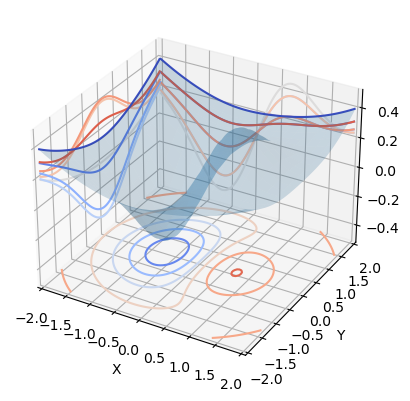

In [90]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib import cm #colormaps

min_val = -2
max_val = 2

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
x_axis = np.linspace(min_val,max_val,100)
y_axis = np.linspace(min_val,max_val,100)
X, Y = np.meshgrid(x_axis, y_axis, copy=False, indexing='xy')
Z = bowl_peak(X,Y)
#X, Y, Z = axes3d.get_test_data(0.05)
ax.plot_surface(X, Y, Z, rstride=5, cstride=5, alpha=0.2)
cset = ax.contour(X, Y, Z, zdir='z', offset=-0.5, cmap=cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir='x', offset=min_val, cmap=cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir='y', offset=max_val, cmap=cm.coolwarm)

ax.set_xlabel('X')
ax.set_xlim(min_val, max_val)
ax.set_ylabel('Y')
ax.set_ylim(min_val, max_val)
ax.set_zlabel('Z')
ax.set_zlim(-0.5, 0.5)

We can see that the minimum lies near $[-\frac{1}{2}, 0]$. We'll use this point to initialize the optimization.
We'll test different methods and compare the outputs obtained.

In [91]:
from scipy import optimize
x0 = np.array([-0.5, 0])
fun = lambda x: bowl_peak(x[0],x[1])
methods = [ 'Nelder-Mead', 'CG', 'BFGS', 'Powell', 'COBYLA', 'L-BFGS-B' ]
for m in methods:
    optim_res = optimize.minimize(fun, x0, method=m)
    print("---\nMethod:{}\n".format(m),optim_res, "\n")

---
Method:Nelder-Mead
        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.4052368582391728
             x: [-6.690e-01 -1.446e-04]
           nit: 20
          nfev: 38
 final_simplex: (array([[-6.690e-01, -1.446e-04],
                       [-6.691e-01, -1.814e-04],
                       [-6.690e-01, -2.011e-04]]), array([-4.052e-01, -4.052e-01, -4.052e-01])) 

---
Method:CG
  message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -0.40523687026669025
       x: [-6.691e-01 -5.670e-09]
     nit: 2
     jac: [ 1.863e-08  0.000e+00]
    nfev: 24
    njev: 8 

---
Method:BFGS
   message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.40523687025688715
        x: [-6.691e-01 -7.451e-09]
      nit: 6
      jac: [-6.083e-06  0.000e+00]
 hess_inv: [[ 5.287e-01 -3.224e-24]
            [-3.224e-24  1.000e+00]]
     nfev: 21
     njev: 7 

---
Method:Powell
  message: Opt

We find a minimum at $-0.4052$ in $[-0.669, 0.000]$ for all converging methods. Note the output message of 'CG' which means that the gradient no longer varies enough. Personally, I don't find this output message very clear. The point found is the optimum sought, however. Note also the number of function evaluations (*nfev*) for each method, and the number of gradient evaluations (*njev*) for methods that rely on a gradient calculation.

Note also that if you rerun *Anneal* several times, you're not guaranteed to get the same solution, since it's a metaheuristic.

In [92]:
for i in range(4):
    optim_res = optimize.minimize(fun, x0, method='BFGS')
    print("---\nMethod:{} - Test:{}\n".format(m,i),optim_res, "\n")

---
Method:L-BFGS-B - Test:0
   message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.40523687025688715
        x: [-6.691e-01 -7.451e-09]
      nit: 6
      jac: [-6.083e-06  0.000e+00]
 hess_inv: [[ 5.287e-01 -3.224e-24]
            [-3.224e-24  1.000e+00]]
     nfev: 21
     njev: 7 

---
Method:L-BFGS-B - Test:1
   message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.40523687025688715
        x: [-6.691e-01 -7.451e-09]
      nit: 6
      jac: [-6.083e-06  0.000e+00]
 hess_inv: [[ 5.287e-01 -3.224e-24]
            [-3.224e-24  1.000e+00]]
     nfev: 21
     njev: 7 

---
Method:L-BFGS-B - Test:2
   message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.40523687025688715
        x: [-6.691e-01 -7.451e-09]
      nit: 6
      jac: [-6.083e-06  0.000e+00]
 hess_inv: [[ 5.287e-01 -3.224e-24]
            [-3.224e-24  1.000e+00]]
     nfev: 21
     njev: 7 

---
Method:L-BFGS-B - Tes

We will evaluate the calculation time required for each method.

In [93]:
for m in methods:
    print("Method:{}:".format(m))
    %timeit optim_res = optimize.minimize(fun, x0, method=m)
    print('############')

Method:Nelder-Mead:
1.84 ms ± 302 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
############
Method:CG:
2.09 ms ± 430 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
############
Method:BFGS:
2.56 ms ± 564 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
############
Method:Powell:
2.09 ms ± 336 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
############
Method:COBYLA:
556 µs ± 48.8 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
############
Method:L-BFGS-B:
3.32 ms ± 1.47 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
############


You can also provide additional arguments to the function you're optimizing. For example, the data when maximizing a log verisimilitude. Here's an example: consider a rescaled version of the *bowl_peak* function. You could also use a lambda function.

In [94]:
def shifted_scaled_bowlpeak(x,a,b,c):
    return (x[0]-a)*np.exp(-((x[0]-a)**2+(x[1]-b)**2))+((x[0]-a)**2+(x[0]-b)**2)/c
a = 2
b = 3
c = 10
optim_res = optimize.minimize(shifted_scaled_bowlpeak, x0, args=(a,b,c), method='BFGS')
print(optim_res)
print('#######')
optim_res = optimize.minimize(lambda x:shifted_scaled_bowlpeak(x,a,b,c), x0, method='BFGS')
print(optim_res)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.05000000677266441
        x: [ 2.500e+00 -1.229e+00]
      nit: 23
      jac: [-9.918e-06  5.635e-08]
 hess_inv: [[ 1.407e+00 -1.579e+02]
            [-1.579e+02  7.174e+05]]
     nfev: 72
     njev: 24
#######
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.05000000677266441
        x: [ 2.500e+00 -1.229e+00]
      nit: 23
      jac: [-9.918e-06  5.635e-08]
 hess_inv: [[ 1.407e+00 -1.579e+02]
            [-1.579e+02  7.174e+05]]
     nfev: 72
     njev: 24


You can continue this little benchmark by adding the gradient and the hessian... the calculations will be faster and more precise.

## Exercise 6: simulation, regression, likelihood maximization estimation

* We begin by simulating the variable $Y = 3 X_1 -2 X_2 +2 + \epsilon$ where $X_1,X_2,\epsilon \sim \mathcal{N}(0,1)$. 
* We then want to find the coefficients in the [linear regression](http://fr.wikipedia.org/wiki/R%C3%A9gression_lin%C3%A9aire) of $Y$ on $X_1$ and $X_2$ in a model with constant, using the Ordinary Least Squares method. Recall that the matrix form of the OLS estimator is $\hat{\beta} = (X'X)^{-1}X'Y$.
* Finally, since $Y$ is normal, we want to estimate its parameters by likelihood maximization:
    * The density is written: $f(x, \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi} } e^{ -\frac{(x-\mu)^2}{2\sigma^2} }$.
    * The log-likelihood: $\ln\mathcal{L}(\mu,\sigma^2) = \sum_{i=1}^n \ln f(x_i;\,\mu,\sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2$.
    * Writing the first-order conditions gives a closed formula for the maximum likelihood estimators: $\hat{\mu} = \overline{x} \equiv \frac{1}{n}\sum_{i=1}^n x_i$, $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \overline{x})^2$.
    * Verify by implementing them directly that you find the same solution as the minimum obtained by using [scipy.optimize.minimize](http://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) to minimize the opposite of the log-likelihood.


## References

* [100 numpy exercises](http://www.loria.fr/~rougier/teaching/numpy.100/)